In [33]:
import hopsworks
import pandas as pd
import numpy as np

# 1. Connect to Hopsworks Feature Store
project = hopsworks.login()
fs = project.get_feature_store(name='aqi_predictor_fsd_featurestore')
fg = fs.get_feature_group('weather_aqi_hourly', version=6)

# 2. Read dataset via Online Store
df = fg.read(online=True)

# 3. Sort chronologically (Online store returns unsorted records)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")

2026-08-23 00:10:55,229 INFO: Closing external client and cleaning up certificates.
2026-08-23 00:10:55,231 INFO: Connection closed.
2026-08-23 00:10:55,232 INFO: Initializing external client
2026-08-23 00:10:55,233 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-23 00:10:59,410 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42119
Dataset shape: (17400, 45)
Date range: 2024-08-24 00:00:00 to 2026-08-18 23:00:00


In [34]:
df.head()

,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,wind_direction_10m,pm2_5,pm10,nitrogen_dioxide,ozone,...,us_aqi_roll_mean_24h,us_aqi_roll_std_24h,us_aqi_roll_min_24h,us_aqi_roll_max_24h,aqi_change_rate_1h,aqi_change_rate_24h,pm25_pm10_ratio,target_aqi_24h,target_aqi_48h,target_aqi_72h
0,2024-08-24 00:00:00,26.5,93,983.4,21.9,48,51.7,83.4,23.1,36.0,...,126.083333,27.770671,98.0,179.0,-0.087687,0.657627,0.619904,150.0,158.0,153.0
1,2024-08-24 01:00:00,28.1,78,982.9,10.7,102,48.9,77.5,21.1,43.0,...,128.125000,27.570167,98.0,179.0,0.057260,0.651757,0.630968,151.0,158.0,151.0
2,2024-08-24 02:00:00,28.5,77,984.0,10.1,86,45.5,72.4,18.3,54.0,...,130.250000,27.190551,98.0,179.0,-0.054159,0.509259,0.628453,151.0,158.0,150.0
3,2024-08-24 03:00:00,29.6,74,984.3,9.0,85,42.3,68.7,15.2,72.0,...,132.458333,26.603333,98.0,179.0,-0.069530,0.358209,0.615720,151.0,159.0,146.0
4,2024-08-24 04:00:00,31.1,69,984.2,10.8,120,40.9,68.7,11.7,103.0,...,134.666667,25.806414,98.0,179.0,-0.070330,0.175000,0.595342,152.0,159.0,143.0


# Data Preprocessing

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17400 entries, 0 to 17399
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  17400 non-null  datetime64[ns]
 1   temperature_2m        17400 non-null  float64       
 2   relative_humidity_2m  17400 non-null  int64         
 3   surface_pressure      17400 non-null  float64       
 4   wind_speed_10m        17400 non-null  float64       
 5   wind_direction_10m    17400 non-null  int64         
 6   pm2_5                 17400 non-null  float64       
 7   pm10                  17400 non-null  float64       
 8   nitrogen_dioxide      17400 non-null  float64       
 9   ozone                 17400 non-null  float64       
 10  us_aqi                17400 non-null  int64         
 11  city                  17400 non-null  object        
 12  wind_u                17400 non-null  float64       
 13  wind_v          

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17400 entries, 0 to 17399
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  17400 non-null  datetime64[ns]
 1   temperature_2m        17400 non-null  float64       
 2   relative_humidity_2m  17400 non-null  int64         
 3   surface_pressure      17400 non-null  float64       
 4   wind_speed_10m        17400 non-null  float64       
 5   wind_direction_10m    17400 non-null  int64         
 6   pm2_5                 17400 non-null  float64       
 7   pm10                  17400 non-null  float64       
 8   nitrogen_dioxide      17400 non-null  float64       
 9   ozone                 17400 non-null  float64       
 10  us_aqi                17400 non-null  int64         
 11  city                  17400 non-null  object        
 12  wind_u                17400 non-null  float64       
 13  wind_v          

In [37]:
df.isna().sum().sum()

np.int64(0)

In [38]:
import pandas as pd

# Select only numeric columns (int, float)
numeric_df = df.select_dtypes(include=['number'])
# Custom aggregate on numeric columns
numeric_metrics = numeric_df.agg(['min', 'max', 'std', 'mean', 'nunique'])
print(numeric_metrics)

         temperature_2m  relative_humidity_2m  surface_pressure  \
min            2.400000              4.000000        969.400000   
max           46.900000            100.000000       1005.500000   
std            8.544813             22.441443          7.039726   
mean          25.318425             58.469253        986.378546   
nunique      429.000000             97.000000        338.000000   

         wind_speed_10m  wind_direction_10m        pm2_5         pm10  \
min            0.000000            1.000000     3.400000     3.400000   
max           38.400000          360.000000   486.200000   804.700000   
std            3.384817           97.716295    67.043822    80.960570   
mean           6.447897          162.960402    83.045483   110.686132   
nunique      227.000000          360.000000  1170.000000  1247.000000   

         nitrogen_dioxide       ozone      us_aqi  ...  us_aqi_roll_mean_24h  \
min              0.000000    0.000000   69.000000  ...             72.541667  

In [39]:
import pandas as pd

target_cols = ["target_aqi_24h", "target_aqi_48h", "target_aqi_72h"]
metadata_cols = ["time", "city"]
feature_cols = [c for c in df.columns if c not in target_cols + metadata_cols]

X = df[feature_cols]
y = df[target_cols]

# 3. Calculate Index Cutoffs (80% Train, 10% Val, 10% Test)
n = len(df)
train_end = int(n * 0.80)
val_end = int(n * 0.90)

# Maximum horizon gap (72 hours) to avoid target overlap
GAP = 72  

# Train set
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

# Validation set (skip GAP rows after train_end)
X_val = X.iloc[train_end + GAP : val_end]
y_val = y.iloc[train_end + GAP : val_end]

# Test set (skip GAP rows after val_end)
X_test = X.iloc[val_end + GAP :]
y_test = y.iloc[val_end + GAP :]

print(f"Train Range: {df['time'].iloc[0]} to {df['time'].iloc[train_end-1]}")
print(f"Val Range:   {df['time'].iloc[train_end+GAP]} to {df['time'].iloc[val_end-1]}")
print(f"Test Range:  {df['time'].iloc[val_end+GAP]} to {df['time'].iloc[-1]}")

Train Range: 2024-08-24 00:00:00 to 2026-03-26 23:00:00
Val Range:   2026-03-30 00:00:00 to 2026-06-07 11:00:00
Test Range:  2026-06-10 12:00:00 to 2026-08-18 23:00:00


Computing Spearman Correlation on TRAINING DATA ONLY (2024-08-24 00:00:00 to 2026-03-26 23:00:00)...

--- TOP FEATURES CORRELATED WITH TARGETS ---

Top 10 features for target_aqi_24h:
us_aqi                  0.823879
us_aqi_lag_1h           0.812913
pm2_5_roll_mean_24h     0.807182
us_aqi_roll_mean_24h    0.755320
us_aqi_roll_min_24h     0.748369
us_aqi_roll_max_24h     0.725314
pm2_5_roll_mean_6h      0.718350
us_aqi_lag_24h          0.714152
pm2_5                   0.712850
pm2_5_roll_std_24h      0.705449
pm2_5_lag_1h            0.693171
us_aqi_lag_48h          0.672881
cos_month               0.668613
us_aqi_lag_72h          0.654475
pm10                    0.615968
surface_pressure        0.614961
pm2_5_lag_24h           0.572989
temperature_2m          0.525641
pm25_pm10_ratio         0.464502
wind_speed_10m          0.422407
Name: target_aqi_24h, dtype: float64

Top 10 features for target_aqi_48h:
us_aqi                  0.713999
us_aqi_lag_1h           0.708202
pm2_5_roll_mean_

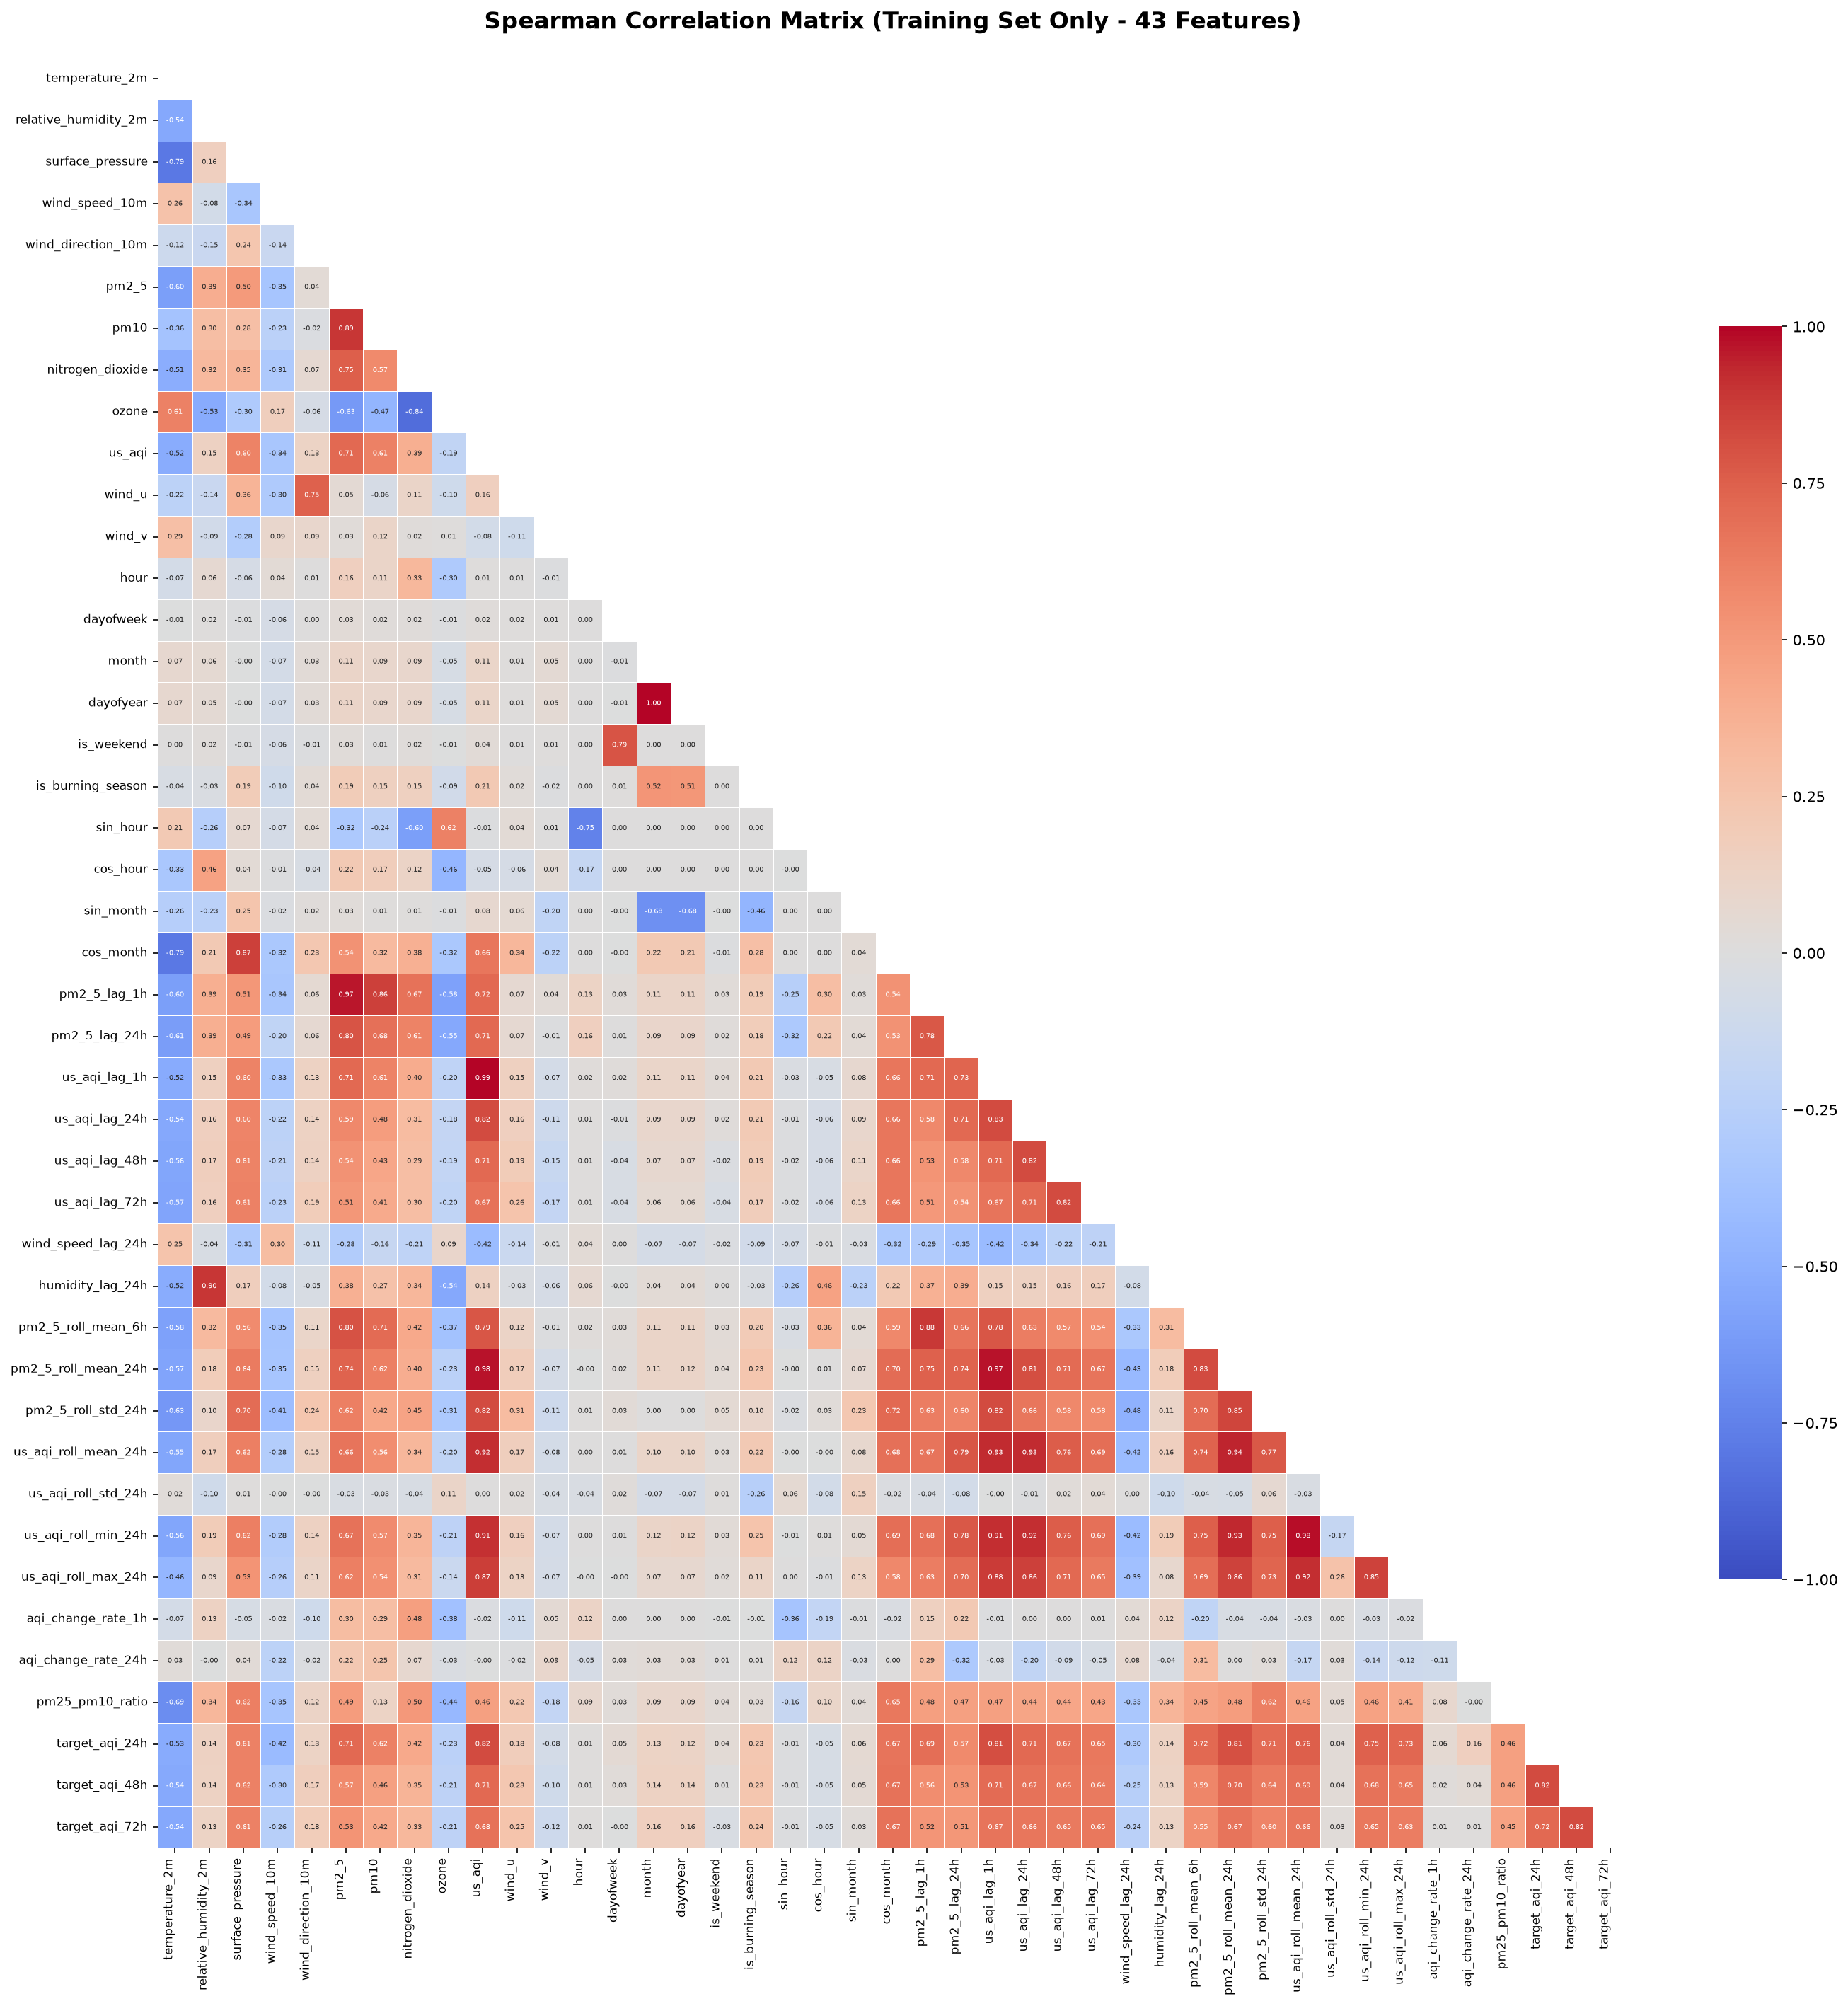

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

n= len(df)
train_end = int(n * 0.80)

# Isolate training set exclusively to compute statistics/correlations
train_df = df.iloc[:train_end].copy()

# Select numeric features for training
numeric_train_df = train_df.select_dtypes(include=[np.number])

print(
    f"Computing Spearman Correlation on TRAINING DATA ONLY ({train_df['time'].iloc[0]} to {train_df['time'].iloc[-1]})..."
)

# 4. Compute Spearman Rank Correlation Matrix
corr_matrix = numeric_train_df.corr(method="spearman")

# 5. Extract Feature Correlation with Target Horizons
print("\n--- TOP FEATURES CORRELATED WITH TARGETS ---")
for target in target_cols:
    if target in corr_matrix.columns:
        top_features = (
            corr_matrix[target]
            .drop(labels=target_cols, errors="ignore")
            .abs()
            .sort_values(ascending=False)
            .head(20)
        )
        print(f"\nTop 10 features for {target}:")
        print(top_features)

# 6. Plot High-Resolution Correlation Heatmap
num_features = numeric_train_df.shape[1]
fig_size = max(18, int(num_features * 0.45))

plt.figure(figsize=(fig_size, fig_size), dpi=150)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={"size": max(5, 140 // num_features)},
    cbar_kws={"shrink": 0.7},
)

plt.title(
    f"Spearman Correlation Matrix (Training Set Only - {num_features} Features)",
    fontsize=16,
    pad=20,
    weight="bold",
)
plt.xticks(rotation=90, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

plt.savefig("train_feature_correlation_matrix_v1.png", dpi=300, bbox_inches="tight")
print("Heatmap saved as 'train_feature_correlation_matrix.png'")
plt.show()

In [45]:
y_train.head()

,target_aqi_24h,target_aqi_48h,target_aqi_72h
0,150.0,158.0,153.0
1,151.0,158.0,151.0
2,151.0,158.0,150.0
3,151.0,159.0,146.0
4,152.0,159.0,143.0


In [46]:
FINAL_FEATURES = [
    # --- Current Primary AQI State ---
    "us_aqi",
    "pm25_pm10_ratio",
    
    # --- Diurnal Lags (24h Cycles) ---
    "us_aqi_lag_24h",
    "us_aqi_lag_48h",
    "us_aqi_lag_72h",
    
    # --- Aggregated Rolling Context ---
    "us_aqi_roll_mean_24h",
    "us_aqi_roll_min_24h",
    "us_aqi_roll_max_24h",
    "us_aqi_roll_std_24h",
    
    # --- Meteorological Signals ---
    "temperature_2m",
    "surface_pressure",
    "wind_speed_10m",
    "wind_u",
    "wind_v",
    
    # --- Cyclical Time Encodings ---
    "cos_month",
    "sin_month",
    "cos_hour",
    "sin_hour",
    "is_weekend"
]

In [64]:
x_train_filtered = X_train[FINAL_FEATURES]
x_test_filtered = X_test[FINAL_FEATURES]

In [65]:
x_train_filtered.agg(['min','mean','median','max','std']).to_json()

'{"us_aqi":{"min":69.0,"mean":172.6563218391,"median":160.0,"max":437.0,"std":57.990034994},"pm25_pm10_ratio":{"min":0.1816021224,"mean":0.7915663808,"median":0.8779527005,"max":0.99999997,"std":0.2071799473},"us_aqi_lag_24h":{"min":69.0,"mean":172.7168103448,"median":160.0,"max":437.0,"std":57.9339807159},"us_aqi_lag_48h":{"min":69.0,"mean":172.6986350575,"median":160.0,"max":437.0,"std":57.9515956619},"us_aqi_lag_72h":{"min":69.0,"mean":172.6302442529,"median":160.0,"max":437.0,"std":58.0154406583},"us_aqi_roll_mean_24h":{"min":72.5416666667,"mean":172.6977699952,"median":159.3333333333,"max":362.0416666667,"std":56.1842426454},"us_aqi_roll_min_24h":{"min":69.0,"mean":157.0265086207,"median":152.0,"max":346.0,"std":53.8074168447},"us_aqi_roll_max_24h":{"min":75.0,"mean":192.1825431034,"median":176.0,"max":437.0,"std":58.3691803562},"us_aqi_roll_std_24h":{"min":0.5036101552,"mean":11.1294443224,"median":8.8575686133,"max":114.8723220028,"std":9.3082118912},"temperature_2m":{"min":2.4,

## Scaling the data for distance based algorithums like Linear Regression

### Linear Regression

In [66]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

x_train_scaled = robust_scaler.fit_transform(x_train_filtered)

In [67]:
x_train_scaled[:5]

array([[-1.96428571e-01, -7.62489916e-01, -1.07142857e+00,
        -9.28571429e-01, -1.10714286e+00, -5.90345848e-01,
        -9.15254237e-01,  5.55555556e-02,  1.85954673e+00,
         1.40740741e-01, -5.08928571e-01,  3.61363636e+00,
        -2.06374690e+00, -2.49476951e+00, -7.32050808e-01,
        -6.33974596e-01,  7.07106781e-01, -4.32978028e-17,
         1.00000000e+00],
       [-1.78571429e-01, -7.29798692e-01, -1.08928571e+00,
        -9.10714286e-01, -1.12500000e+00, -5.54096542e-01,
        -9.15254237e-01,  5.55555556e-02,  1.83983314e+00,
         2.59259259e-01, -5.53571429e-01,  1.06818182e+00,
        -1.26566402e+00,  3.10697429e-01, -7.32050808e-01,
        -6.33974596e-01,  6.83012702e-01,  1.83012702e-01,
         1.00000000e+00],
       [-1.60714286e-01, -7.37229227e-01, -1.10714286e+00,
        -8.92857143e-01, -1.12500000e+00, -5.16367672e-01,
        -9.15254237e-01,  5.55555556e-02,  1.80250909e+00,
         2.88888889e-01, -4.55357143e-01,  9.31818182e-01,
    

In [75]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
y_train_24h = y_train['target_aqi_24h']
model.fit(X=x_train_scaled,y=y_train_24h)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](19,)","[46.28,-5.43,11.76,...,-4.28, 0.59,-0.52]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,164.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](19,)","[305.14,124.17,106.72,..., 17.61, 9.77, 6.41]"


In [76]:
x_test_scaled = robust_scaler.transform(x_test_filtered)
y_pred = model.predict(x_test_scaled)

In [77]:
y_test.head

<bound method NDFrame.head of        target_aqi_24h  target_aqi_48h  target_aqi_72h
15732           185.0           189.0           198.0
15733           189.0           212.0           184.0
15734           184.0           245.0           170.0
15735           172.0           263.0           159.0
15736           159.0           268.0           156.0
...               ...             ...             ...
17395           161.0           154.0           157.0
17396           161.0           154.0           157.0
17397           160.0           154.0           157.0
17398           160.0           154.0           157.0
17399           159.0           154.0           157.0

[1668 rows x 3 columns]>

In [79]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score


results_linear_24h = []
y_test_24h = y_test['target_aqi_24h']
mse = mean_squared_error(y_test_24h, y_pred)
rmse = root_mean_squared_error(y_test_24h, y_pred)
mae = mean_absolute_error(y_test_24h, y_pred)
mape = mean_absolute_percentage_error(y_test_24h, y_pred)
r2 = r2_score(y_test_24h, y_pred)

results_linear_24h.append({
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape,
    "R2 Score": r2
})

print(results_linear_24h)

[{'MSE': 646.6080037487898, 'RMSE': 25.428488035052137, 'MAE': 18.99775839901698, 'MAPE': 0.12552252891574756, 'R2 Score': 0.011839208197228612}]


### Decision Tree

In [85]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=42)
decision_tree_model.fit(X=x_train_filtered,y=y_train_24h)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes ma

In [86]:
y_pred_decision_tree = decision_tree_model.predict(x_test_filtered)

results_decision_tree_24h = []
mse = mean_squared_error(y_test_24h, y_pred_decision_tree)
rmse = root_mean_squared_error(y_test_24h, y_pred_decision_tree)
mae = mean_absolute_error(y_test_24h, y_pred_decision_tree)
mape = mean_absolute_percentage_error(y_test_24h, y_pred_decision_tree)
r2 = r2_score(y_test_24h, y_pred_decision_tree)

results_decision_tree_24h.append({
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape,
    "R2 Score": r2
})

print(results_decision_tree_24h)

[{'MSE': 638.96854830346, 'RMSE': 25.27782720693098, 'MAE': 19.574236701286686, 'MAPE': 0.1337081907347313, 'R2 Score': 0.023513994618109324}]


In [87]:
print("Train R2:", r2_score(y_train_24h, decision_tree_model.predict(x_train_filtered)))

Train R2: 0.7441180228956769


In [88]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ── 1. Persistence baseline: naive "tomorrow's AQI = today's AQI" ──
baseline_pred = x_test_filtered['us_aqi']
print("=== Persistence Baseline (24h) ===")
print("R2: ", r2_score(y_test_24h, baseline_pred))
print("MAE:", mean_absolute_error(y_test_24h, baseline_pred))

# ── 2. Distribution shift check: train vs test feature stats ──
print("\n=== Train vs Test feature stats (us_aqi) ===")
print("Train:", x_train_filtered['us_aqi'].agg(['min', 'mean', 'median', 'max', 'std']).to_dict())
print("Test: ", x_test_filtered['us_aqi'].agg(['min', 'mean', 'median', 'max', 'std']).to_dict())

print("\n=== Train vs Test target stats (target_aqi_24h) ===")
print("Train:", y_train_24h.agg(['min', 'mean', 'median', 'max', 'std']).to_dict())
print("Test: ", y_test_24h.agg(['min', 'mean', 'median', 'max', 'std']).to_dict())

# ── 3. Constrained decision tree, train vs test R2 side by side ──
tree_model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=42)
tree_model.fit(X=x_train_filtered, y=y_train_24h)

train_pred = tree_model.predict(x_train_filtered)
test_pred = tree_model.predict(x_test_filtered)

print("\n=== Constrained Tree (24h) ===")
print("Train R2:", r2_score(y_train_24h, train_pred))
print("Test R2: ", r2_score(y_test_24h, test_pred))
print("Test MAE:", mean_absolute_error(y_test_24h, test_pred))

=== Persistence Baseline (24h) ===
R2:  -0.15192506925235305
MAE: 20.276378896882495

=== Train vs Test feature stats (us_aqi) ===
Train: {'min': 69.0, 'mean': 172.65632183908045, 'median': 160.0, 'max': 437.0, 'std': 57.990034994031205}
Test:  {'min': 82.0, 'mean': 151.90167865707434, 'median': 154.0, 'max': 268.0, 'std': 25.588008440374313}

=== Train vs Test target stats (target_aqi_24h) ===
Train: {'min': 69.0, 'mean': 172.5594827586207, 'median': 160.0, 'max': 437.0, 'std': 58.07426958651707}
Test:  {'min': 82.0, 'mean': 151.92745803357315, 'median': 154.0, 'max': 268.0, 'std': 25.588035953086553}

=== Constrained Tree (24h) ===
Train R2: 0.7441180228956769
Test R2:  0.023513994618109324
Test MAE: 19.574236701286686
